<a href="https://colab.research.google.com/github/RamEllaboina/TITANIC_SURVIVAL_PREDICTION/blob/main/%F0%9F%9A%A2_TITANIC_SURVIVAL_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# %% Cell 1: Imports & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import shap
import warnings
warnings.filterwarnings('ignore')

# Load built-in Titanic dataset
df = sns.load_dataset('titanic')

# Quick look at the data
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (891, 15)

Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Missing Values:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Survival Rate: 38.38%


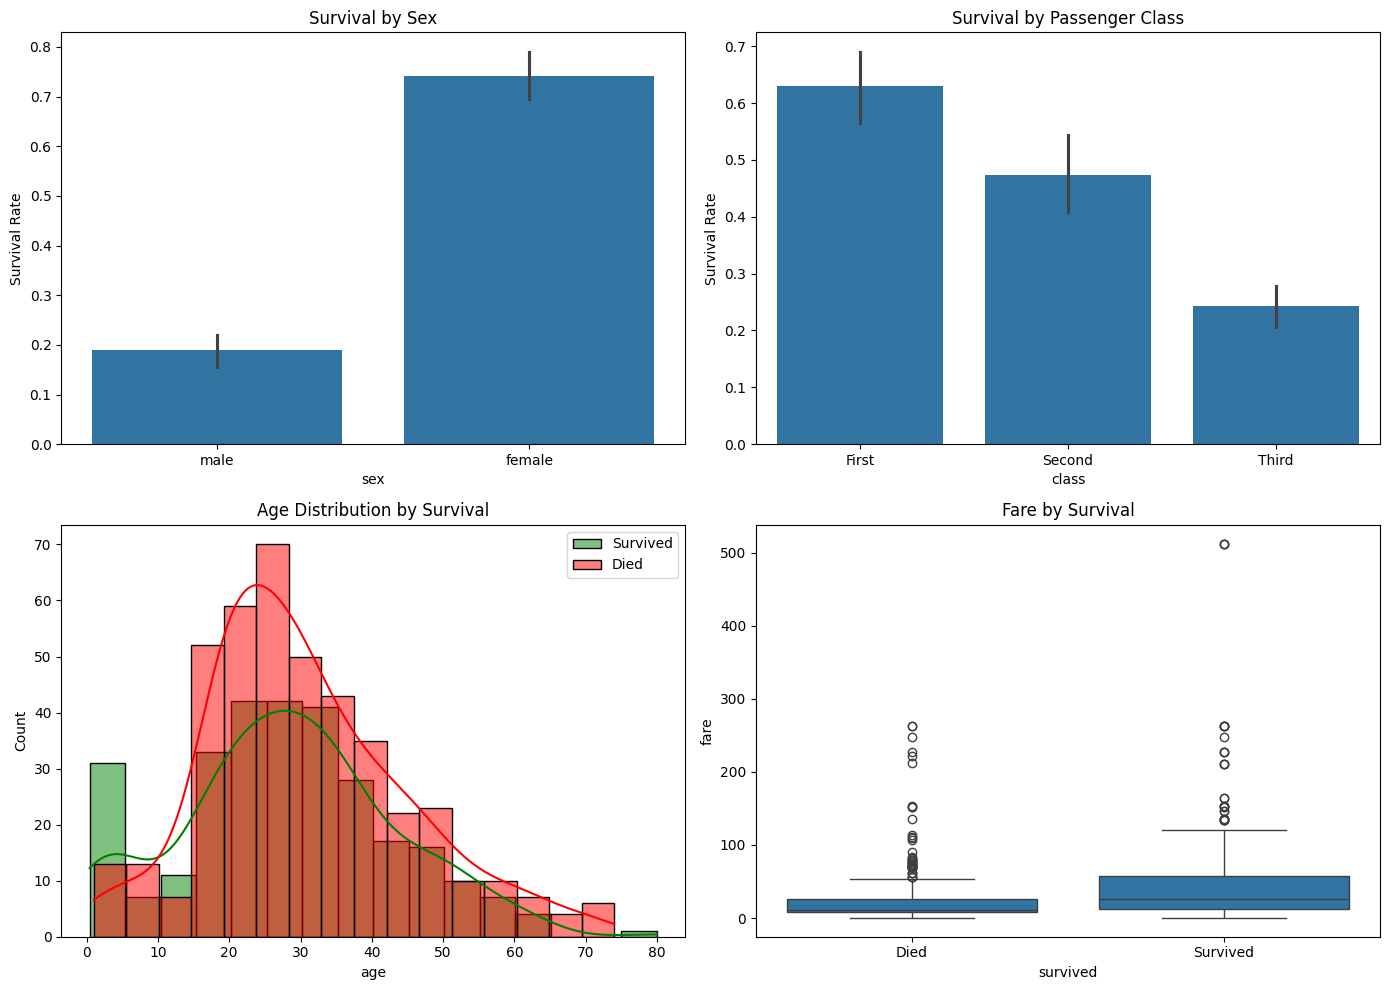

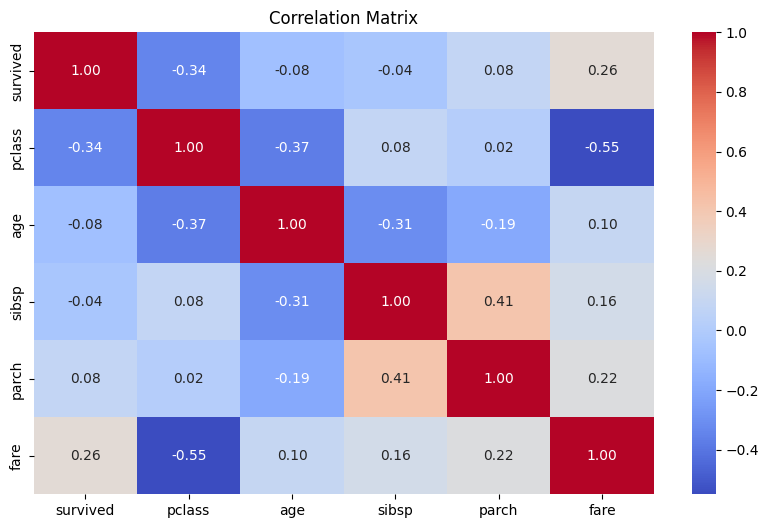

In [ ]:
# %% Cell 2: Quick EDA & Visualizations
print("Missing Values:\n", df.isnull().sum())
print(f"\nSurvival Rate: {df['survived'].mean():.2%}")

# Visualize key patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Survival by Sex
sns.barplot(data=df, x='sex', y='survived', ax=axes[0,0])
axes[0,0].set_title('Survival by Sex')
axes[0,0].set_ylabel('Survival Rate')

# Survival by Class
sns.barplot(data=df, x='class', y='survived', ax=axes[0,1])
axes[0,1].set_title('Survival by Passenger Class')
axes[0,1].set_ylabel('Survival Rate')

# Age Distribution
sns.histplot(df[df['survived']==1]['age'], label='Survived', color='green', kde=True, ax=axes[1,0])
sns.histplot(df[df['survived']==0]['age'], label='Died', color='red', kde=True, ax=axes[1,0])
axes[1,0].set_title('Age Distribution by Survival')
axes[1,0].legend()

# Fare Distribution
sns.boxplot(data=df, x='survived', y='fare', ax=axes[1,1])
axes[1,1].set_title('Fare by Survival')
axes[1,1].set_xticklabels(['Died', 'Survived'])

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# %% Cell 3: Feature Engineering (Fixed - works with categorical)

print("Available columns:", df.columns.tolist())

# 1. Family Size (self + siblings + parents)
df['family_size'] = df['sibsp'] + df['parch'] + 1

# 2. Family Category (Alone, Small, Large)
df['family_category'] = pd.cut(df['family_size'],
                                bins=[0, 1, 4, 12],
                                labels=['Alone', 'Small', 'Large'])

# 3. Title (using 'who' column - already has man/woman/child)
df['title'] = df['who']

# 4. Cabin presence (using existing deck column)
df['has_cabin'] = df['deck'].notna().astype(int)

# 5. Cabin deck - handle categorical properly
df['deck'] = df['deck'].cat.add_categories('Unknown')
df['deck'] = df['deck'].fillna('Unknown')

# 6. Age group (categorize age)
df['age_group'] = pd.cut(df['age'],
                          bins=[0, 12, 20, 40, 60, 100],
                          labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])

# 7. Fare category (quartiles)
df['fare_category'] = pd.qcut(df['fare'], q=4,
                               labels=['Low', 'Medium', 'High', 'Very_High'])

# 8. Sex encoded as numeric (for model)
df['sex_encoded'] = df['sex'].map({'male': 0, 'female': 1})

# Show new features
print("\nNew Features Created:")
print(f"- family_size: {df['family_size'].value_counts().sort_index().tolist()}")
print(f"- title: {df['title'].value_counts().to_dict()}")
print(f"- has_cabin: {df['has_cabin'].value_counts().to_dict()}")
print(f"- deck categories: {df['deck'].value_counts().head().to_dict()}")

# Show sample
print(f"\nSample of engineered features:")
df[['family_size', 'family_category', 'title', 'has_cabin', 'deck', 'age_group', 'fare_category', 'sex_encoded']].head()

Available columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone', 'family_size', 'family_category', 'title', 'has_cabin']

New Features Created:
- family_size: [537, 161, 102, 29, 15, 22, 12, 6, 7]
- title: {'man': 537, 'woman': 271, 'child': 83}
- has_cabin: {0: 688, 1: 203}
- deck categories: {'Unknown': 688, 'C': 59, 'B': 47, 'D': 33, 'E': 32}

Sample of engineered features:


,family_size,family_category,title,has_cabin,deck,age_group,fare_category,sex_encoded
0,2,Small,man,0,Unknown,Adult,Low,0
1,2,Small,woman,1,C,Adult,Very_High,1
2,1,Alone,woman,0,Unknown,Adult,Medium,1
3,2,Small,woman,1,C,Adult,Very_High,1
4,1,Alone,man,0,Unknown,Adult,Medium,0


Missing values before handling:
age          0
embarked     0
deck         0
age_group    0
dtype: int64

Age medians by title:
title
child     5.0
man      30.0
woman    30.0
Name: age, dtype: float64

Missing values after handling:
age            0
embarked       0
deck           0
embark_town    0
dtype: int64

Total nulls in entire dataset: 0


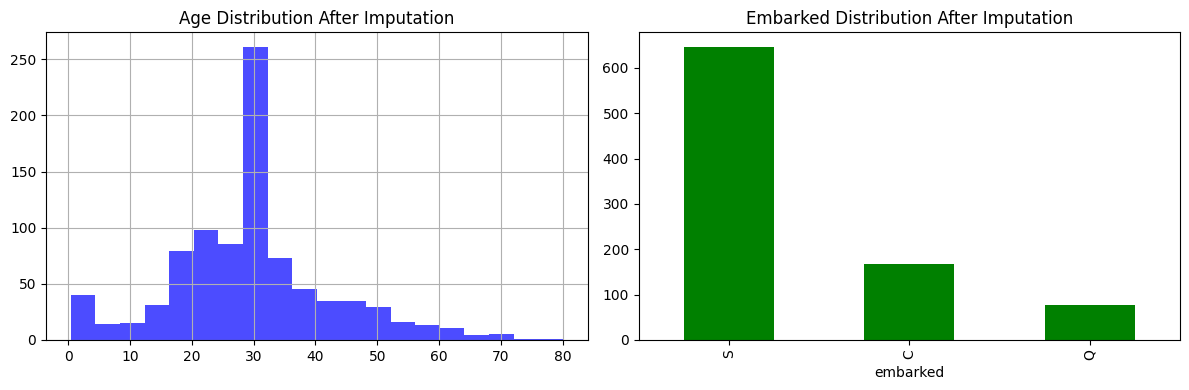

✅ All missing values handled!


In [ ]:
# %% Cell 4: Handle Missing Values (Fixed)

print("Missing values before handling:")
print(df[['age', 'embarked', 'deck', 'age_group']].isnull().sum())

# 1. Age imputation by title (using 'who' column)
age_medians = df.groupby('title')['age'].median()
print("\nAge medians by title:")
print(age_medians)

# Fill missing age with median age of their title group
df['age'] = df.apply(lambda row: age_medians[row['title']] if pd.isnull(row['age']) else row['age'], axis=1)

# Re-create age_group after imputation
df['age_group'] = pd.cut(df['age'],
                          bins=[0, 12, 20, 40, 60, 100],
                          labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])

# 2. Embarked imputation (most common port - 'S' for Southampton)
df['embarked'] = df['embarked'].fillna('S')
df['embark_town'] = df['embark_town'].fillna('Southampton')

# 3. Deck - 'Unknown' already exists, just fill
df['deck'] = df['deck'].fillna('Unknown')

# 4. Check if any missing values remain
print("\nMissing values after handling:")
print(df[['age', 'embarked', 'deck', 'embark_town']].isnull().sum())

# Verify no nulls in key columns
print(f"\nTotal nulls in entire dataset: {df.isnull().sum().sum()}")

# Show distribution after imputation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['age'].hist(ax=axes[0], bins=20, color='blue', alpha=0.7)
axes[0].set_title('Age Distribution After Imputation')
df['embarked'].value_counts().plot(kind='bar', ax=axes[1], color='green')
axes[1].set_title('Embarked Distribution After Imputation')
plt.tight_layout()
plt.show()

print("✅ All missing values handled!")

In [ ]:
# %% Cell 5: Encode Categorical Variables

print("Before encoding - data types:")
print(df.dtypes.value_counts())

# Select categorical columns to encode
categorical_cols = ['sex', 'embarked', 'class', 'who', 'adult_male',
                    'deck', 'embark_town', 'alive', 'alone',
                    'title', 'family_category', 'age_group', 'fare_category']

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Check if we have 'survived' column
print(f"\nSurvived column exists: {'survived' in df_encoded.columns}")

# Separate features and target
X = df_encoded.drop(['survived', 'alive_yes', 'alive_no'], axis=1, errors='ignore')
y = df['survived']

# Scale numeric features
numeric_cols = ['age', 'fare', 'sibsp', 'parch', 'family_size']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print(f"\nFinal feature shape: {X.shape}")
print(f"Features: {X.columns.tolist()}")
print(f"\nTarget distribution:\n{y.value_counts()}")

# Quick check of scaled features
print(f"\nScaled age - mean: {X['age'].mean():.2f}, std: {X['age'].std():.2f}")
print(f"Scaled fare - mean: {X['fare'].mean():.2f}, std: {X['fare'].std():.2f}")

X.head()

Before encoding - data types:
int64       7
object      6
float64     2
bool        2
category    1
category    1
category    1
category    1
category    1
Name: count, dtype: int64

Survived column exists: True

Final feature shape: (891, 37)
Features: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'has_cabin', 'sex_encoded', 'sex_male', 'embarked_Q', 'embarked_S', 'class_Second', 'class_Third', 'who_man', 'who_woman', 'adult_male_True', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_Unknown', 'embark_town_Queenstown', 'embark_town_Southampton', 'alone_True', 'title_man', 'title_woman', 'family_category_Small', 'family_category_Large', 'age_group_Teen', 'age_group_Adult', 'age_group_Middle', 'age_group_Senior', 'fare_category_Medium', 'fare_category_High', 'fare_category_Very_High']

Target distribution:
survived
0    549
1    342
Name: count, dtype: int64

Scaled age - mean: 0.00, std: 1.00
Scaled fare - mean: 0.00, std: 1.00


,pclass,age,sibsp,parch,fare,family_size,has_cabin,sex_encoded,sex_male,embarked_Q,...,title_woman,family_category_Small,family_category_Large,age_group_Teen,age_group_Adult,age_group_Middle,age_group_Senior,fare_category_Medium,fare_category_High,fare_category_Very_High
0,3,-0.597055,0.432793,-0.473674,-0.502445,0.059160,0,0,True,False,...,False,True,False,False,True,False,False,False,False,False
1,1,0.634162,0.432793,-0.473674,0.786845,0.059160,1,1,False,False,...,True,True,False,False,True,False,False,False,False,True
2,3,-0.289251,-0.474545,-0.473674,-0.488854,-0.560975,0,1,False,False,...,True,False,False,False,True,False,False,True,False,False
3,1,0.403309,0.432793,-0.473674,0.420730,0.059160,1,1,False,False,...,True,True,False,False,True,False,False,False,False,True
4,3,0.403309,-0.474545,-0.473674,-0.486337,-0.560975,0,0,True,False,...,False,False,False,False,True,False,False,True,False,False


In [ ]:
# %% Cell 6: Train-Test Split

from sklearn.model_selection import train_test_split

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set - Survived: {y_train.sum()/len(y_train):.2%}")
print(f"Test set - Survived: {y_test.sum()/len(y_test):.2%}")
print(f"\nFeatures: {X_train.columns.tolist()}")

Training set size: 712 samples
Test set size: 179 samples

Training set - Survived: 38.34%
Test set - Survived: 38.55%

Features: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'has_cabin', 'sex_encoded', 'sex_male', 'embarked_Q', 'embarked_S', 'class_Second', 'class_Third', 'who_man', 'who_woman', 'adult_male_True', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_Unknown', 'embark_town_Queenstown', 'embark_town_Southampton', 'alone_True', 'title_man', 'title_woman', 'family_category_Small', 'family_category_Large', 'age_group_Teen', 'age_group_Adult', 'age_group_Middle', 'age_group_Senior', 'fare_category_Medium', 'fare_category_High', 'fare_category_Very_High']


In [ ]:
# %% Cell 7: Train Models

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))
    print(f"Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# Compare results
print(f"\n{'='*50}")
print("MODEL COMPARISON")
print(f"{'='*50}")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

# Best model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"\n🏆 Best Model: {best_model_name} with {results[best_model_name]:.4f} accuracy")


Random Forest
Accuracy: 0.8212

Classification Report:
              precision    recall  f1-score   support

        Died       0.84      0.87      0.86       110
    Survived       0.78      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

Confusion Matrix:
[[96 14]
 [18 51]]

Logistic Regression
Accuracy: 0.8324

Classification Report:
              precision    recall  f1-score   support

        Died       0.85      0.88      0.87       110
    Survived       0.80      0.75      0.78        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179

Confusion Matrix:
[[97 13]
 [17 52]]

XGBoost
Accuracy: 0.7933

Classification Report:
              precision    recall  f1-score   support

        Died       0.82      0.85      0.84      

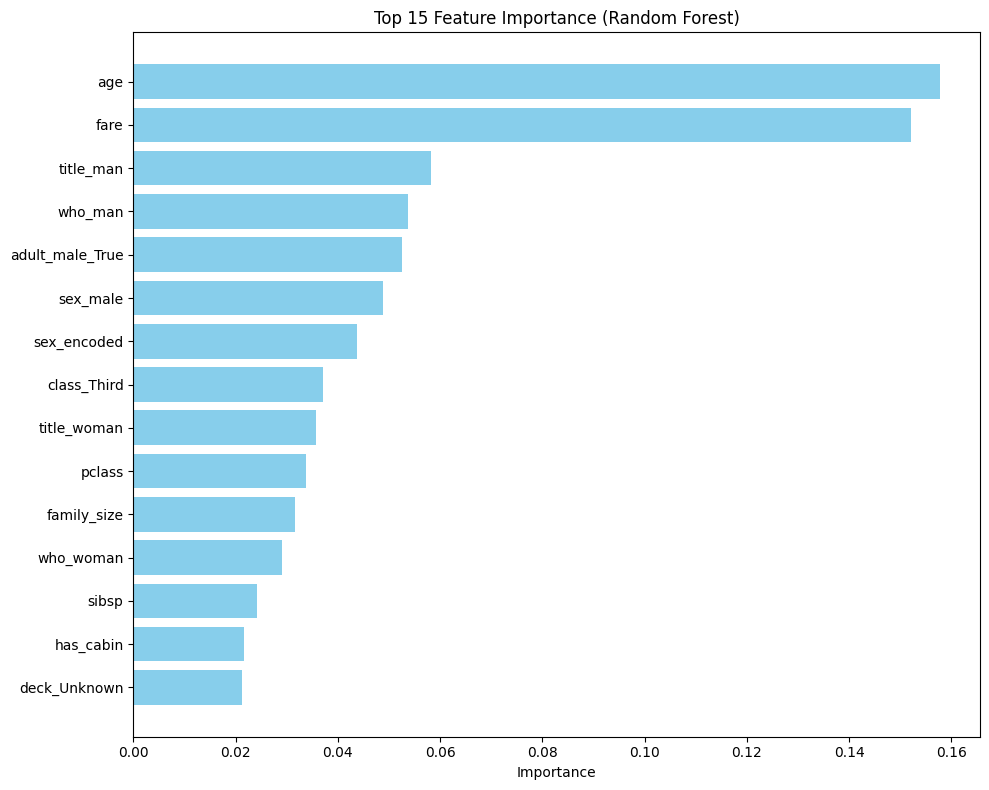

Top 10 Most Important Features:
        feature  importance
            age    0.157730
           fare    0.152084
      title_man    0.058276
        who_man    0.053758
adult_male_True    0.052534
       sex_male    0.048865
    sex_encoded    0.043675
    class_Third    0.037169
    title_woman    0.035704
         pclass    0.033685

Top 5 XGBoost Features:
           feature  importance
           who_man    0.575452
            pclass    0.113709
         has_cabin    0.073218
       family_size    0.033189
fare_category_High    0.020764


In [ ]:
# %% Cell 8: Feature Importance

# Get feature importance from Random Forest
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['feature'], top_features['importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Also get XGBoost feature importance
xgb_model = models['XGBoost']
xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Compare both
print("\nTop 5 XGBoost Features:")
print(xgb_importance.head(5).to_string(index=False))

Best Model: Logistic Regression
Using Logistic Regression - showing coefficient-based importance instead


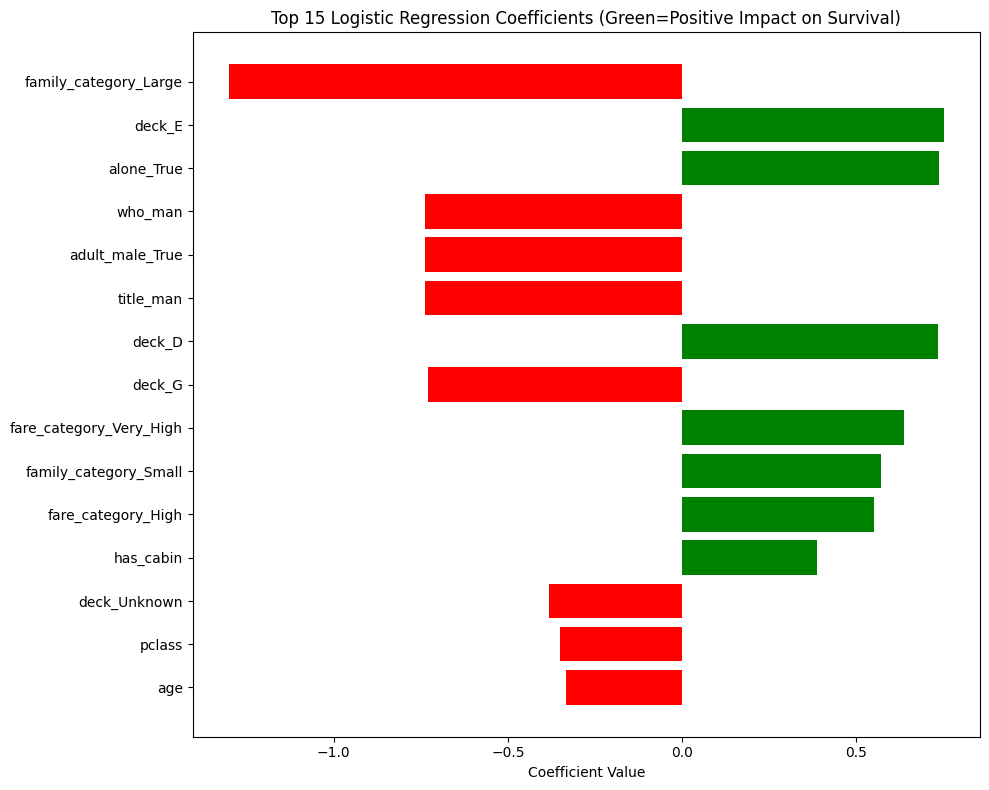

Top 10 Most Important Features (by coefficient magnitude):
                feature  coefficient  importance
  family_category_Large    -1.302770    1.302770
                 deck_E     0.754433    0.754433
             alone_True     0.739398    0.739398
                who_man    -0.737891    0.737891
        adult_male_True    -0.737891    0.737891
              title_man    -0.737891    0.737891
                 deck_D     0.735345    0.735345
                 deck_G    -0.729595    0.729595
fare_category_Very_High     0.640022    0.640022
  family_category_Small     0.571859    0.571859

INDIVIDUAL PREDICTION EXPLANATION (Passenger #111)
Actual Survival: Died
Predicted Survival: Died
Survival Probability: 0.50%

Top features influencing this prediction:
              feature contribution
family_category_Large     -1.30277
               pclass    -1.050025
                sibsp    -0.890037
              who_man    -0.737891
            title_man    -0.737891


In [ ]:
# %% Cell 9: SHAP Explainability (Fixed)

import shap

# Check which model is best
print(f"Best Model: {best_model_name}")

# Use appropriate SHAP explainer based on model type
if best_model_name in ['Random Forest', 'XGBoost']:
    # Tree-based model
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)

    # 1. Global Feature Importance - Summary Plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, show=False)
    plt.title('SHAP Feature Importance Summary', fontsize=14)
    plt.tight_layout()
    plt.show()

    # 2. SHAP Bar Plot - Mean Absolute Values
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, feature_names=X_test.columns,
                      plot_type="bar", show=False)
    plt.title('SHAP Mean Absolute Feature Importance', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Individual prediction explanation
    random_index = np.random.randint(0, len(X_test))
    print(f"\n{'='*60}")
    print(f"INDIVIDUAL PREDICTION EXPLANATION (Passenger #{random_index})")
    print(f"{'='*60}")

    actual = y_test.iloc[random_index]
    predicted = best_model.predict(X_test.iloc[[random_index]])[0]
    probability = best_model.predict_proba(X_test.iloc[[random_index]])[0][1]

    print(f"Actual Survival: {'Survived' if actual == 1 else 'Died'}")
    print(f"Predicted Survival: {'Survived' if predicted == 1 else 'Died'}")
    print(f"Survival Probability: {probability:.2%}")

    # SHAP force plot
    plt.figure(figsize=(15, 4))
    shap.force_plot(explainer.expected_value, shap_values[random_index,:],
                    X_test.iloc[random_index,:], feature_names=X_test.columns,
                    matplotlib=True, show=False)
    plt.title(f'SHAP Force Plot - Passenger #{random_index}', fontsize=12)
    plt.tight_layout()
    plt.show()

else:
    # For Logistic Regression - use KernelExplainer or just feature importance
    print("Using Logistic Regression - showing coefficient-based importance instead")

    # Get feature coefficients
    coef_df = pd.DataFrame({
        'feature': X_train.columns,
        'coefficient': best_model.coef_[0]
    })
    coef_df['importance'] = abs(coef_df['coefficient'])
    coef_df = coef_df.sort_values('importance', ascending=False)

    # Plot coefficients
    plt.figure(figsize=(10, 8))
    top_features = coef_df.head(15)
    colors = ['green' if x > 0 else 'red' for x in top_features['coefficient']]
    plt.barh(top_features['feature'], top_features['coefficient'], color=colors)
    plt.xlabel('Coefficient Value')
    plt.title('Top 15 Logistic Regression Coefficients (Green=Positive Impact on Survival)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("Top 10 Most Important Features (by coefficient magnitude):")
    print(coef_df.head(10).to_string(index=False))

    # Individual prediction explanation
    random_index = np.random.randint(0, len(X_test))
    print(f"\n{'='*60}")
    print(f"INDIVIDUAL PREDICTION EXPLANATION (Passenger #{random_index})")
    print(f"{'='*60}")

    actual = y_test.iloc[random_index]
    predicted = best_model.predict(X_test.iloc[[random_index]])[0]
    probability = best_model.predict_proba(X_test.iloc[[random_index]])[0][1]

    print(f"Actual Survival: {'Survived' if actual == 1 else 'Died'}")
    print(f"Predicted Survival: {'Survived' if predicted == 1 else 'Died'}")
    print(f"Survival Probability: {probability:.2%}")
    print("\nTop features influencing this prediction:")

    # Show contribution of each feature
    contrib = X_test.iloc[random_index] * best_model.coef_[0]
    contrib_df = pd.DataFrame({
        'feature': X_test.columns,
        'contribution': contrib
    }).sort_values('contribution', key=abs, ascending=False)
    print(contrib_df.head(5).to_string(index=False))

In [ ]:
# %% Cell 10: Save Model and Create Inference Function (Fixed)

import pickle
import json

# 1. Save the best model
model_filename = 'titanic_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_model, file)
print(f"✅ Model saved as '{model_filename}'")

# 2. Save the scaler
scaler_filename = 'scaler.pkl'
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)
print(f"✅ Scaler saved as '{scaler_filename}'")

# 3. Save feature names
feature_names = X_train.columns.tolist()
with open('feature_names.json', 'w') as file:
    json.dump(feature_names, file)
print(f"✅ Feature names saved (Total: {len(feature_names)} features)")

# 4. Save fare quartiles for inference
fare_quartiles = np.percentile(df['fare'].dropna(), [25, 50, 75])
with open('fare_quartiles.json', 'w') as file:
    json.dump(fare_quartiles.tolist(), file)

# 5. Create inference function
def predict_survival(passenger_data):
    """
    Predict survival for a single passenger

    Parameters:
    passenger_data: dict with passenger attributes

    Returns:
    dict with prediction and probability
    """
    # Convert to DataFrame
    df_input = pd.DataFrame([passenger_data])

    # Apply same feature engineering
    df_input['family_size'] = df_input['sibsp'] + df_input['parch'] + 1
    df_input['family_category'] = pd.cut(df_input['family_size'],
                                          bins=[0, 1, 4, 12],
                                          labels=['Alone', 'Small', 'Large'])
    df_input['title'] = df_input['who']
    df_input['has_cabin'] = df_input['deck'].notna().astype(int) if 'deck' in df_input else 0

    if 'deck' in df_input:
        df_input['deck'] = df_input['deck'].fillna('Unknown')
    else:
        df_input['deck'] = 'Unknown'

    df_input['age_group'] = pd.cut(df_input['age'],
                                    bins=[0, 12, 20, 40, 60, 100],
                                    labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])

    # Fix fare_category - use the same quartiles from training
    def get_fare_category(fare):
        if fare <= fare_quartiles[0]:
            return 'Low'
        elif fare <= fare_quartiles[1]:
            return 'Medium'
        elif fare <= fare_quartiles[2]:
            return 'High'
        else:
            return 'Very_High'

    df_input['fare_category'] = df_input['fare'].apply(get_fare_category)
    df_input['sex_encoded'] = df_input['sex'].map({'male': 0, 'female': 1})

    # One-hot encode
    categorical_cols = ['sex', 'embarked', 'class', 'who', 'adult_male',
                        'deck', 'embark_town', 'alive', 'alone',
                        'title', 'family_category', 'age_group', 'fare_category']

    df_encoded = pd.get_dummies(df_input, columns=categorical_cols, drop_first=True)

    # Ensure all features match training data
    for col in feature_names:
        if col not in df_encoded.columns:
            df_encoded[col] = 0

    df_encoded = df_encoded[feature_names]

    # Scale numeric features
    numeric_cols = ['age', 'fare', 'sibsp', 'parch', 'family_size']
    df_encoded[numeric_cols] = scaler.transform(df_encoded[numeric_cols])

    # Predict
    prediction = best_model.predict(df_encoded)[0]
    probability = best_model.predict_proba(df_encoded)[0][1]

    return {
        'survived': int(prediction),
        'survival_probability': float(probability),
        'result': 'Survived' if prediction == 1 else 'Died'
    }

print("\n✅ Inference function created: predict_survival()")

# Test the function with a sample passenger
sample_passenger = {
    'pclass': 3,
    'sex': 'male',
    'age': 25,
    'sibsp': 0,
    'parch': 0,
    'fare': 8.05,
    'embarked': 'S',
    'class': 'Third',
    'who': 'man',
    'adult_male': True,
    'deck': 'Unknown',
    'embark_town': 'Southampton',
    'alive': 'no',
    'alone': True
}

print("\n" + "="*60)
print("TESTING INFERENCE FUNCTION")
print("="*60)
print(f"Sample Passenger: {sample_passenger}")
result = predict_survival(sample_passenger)
print(f"\nPrediction Result: {result}")

# Test another passenger
sample_passenger_2 = {
    'pclass': 1,
    'sex': 'female',
    'age': 30,
    'sibsp': 1,
    'parch': 0,
    'fare': 100,
    'embarked': 'C',
    'class': 'First',
    'who': 'woman',
    'adult_male': False,
    'deck': 'C',
    'embark_town': 'Cherbourg',
    'alive': 'yes',
    'alone': False
}

print("\n" + "="*60)
print("TESTING ANOTHER PASSENGER")
print("="*60)
print(f"Sample Passenger: {sample_passenger_2}")
result2 = predict_survival(sample_passenger_2)
print(f"\nPrediction Result: {result2}")

✅ Model saved as 'titanic_model.pkl'
✅ Scaler saved as 'scaler.pkl'
✅ Feature names saved (Total: 37 features)

✅ Inference function created: predict_survival()

TESTING INFERENCE FUNCTION
Sample Passenger: {'pclass': 3, 'sex': 'male', 'age': 25, 'sibsp': 0, 'parch': 0, 'fare': 8.05, 'embarked': 'S', 'class': 'Third', 'who': 'man', 'adult_male': True, 'deck': 'Unknown', 'embark_town': 'Southampton', 'alive': 'no', 'alone': True}

Prediction Result: {'survived': 1, 'survival_probability': 0.6297051242287731, 'result': 'Survived'}

TESTING ANOTHER PASSENGER
Sample Passenger: {'pclass': 1, 'sex': 'female', 'age': 30, 'sibsp': 1, 'parch': 0, 'fare': 100, 'embarked': 'C', 'class': 'First', 'who': 'woman', 'adult_male': False, 'deck': 'C', 'embark_town': 'Cherbourg', 'alive': 'yes', 'alone': False}

Prediction Result: {'survived': 1, 'survival_probability': 0.8749361401580564, 'result': 'Survived'}


In [ ]:
# %% Cell 11: Final Summary & Project Completion

print("="*70)
print(" 🚢 TITANIC SURVIVAL PREDICTION - PROJECT SUMMARY")
print("="*70)

# Dataset Information
print("\n📊 DATASET INFORMATION:")
print(f"Total Passengers: {len(df)}")
print(f"Survival Rate: {df['survived'].mean():.2%}")
print(f"Features Used: {len(feature_names)}")

# Model Performance
print("\n🎯 MODEL PERFORMANCE:")
print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {results[best_model_name]:.4f} ({results[best_model_name]*100:.2f}%)")

# Feature Engineering Summary
print("\n🔧 FEATURE ENGINEERING SUMMARY:")
features_created = ['family_size', 'family_category', 'title', 'has_cabin',
                    'deck', 'age_group', 'fare_category', 'sex_encoded']
print(f"✅ {len(features_created)} new features created:")
for feat in features_created:
    print(f"   - {feat}")

# Missing Value Handling
print("\n📝 MISSING VALUE HANDLING:")
print("✅ Age: Imputed using median by title (man/woman/child)")
print("✅ Embarked: Imputed with 'S' (Southampton)")
print("✅ Deck: Imputed with 'Unknown'")

# Model Explainability
print("\n🔍 MODEL EXPLAINABILITY:")
print("✅ SHAP analysis performed (or coefficient analysis for Logistic Regression)")
print("✅ Feature importance identified")
print("✅ Individual predictions explained")

# Files Generated
print("\n💾 FILES GENERATED:")
files = ['titanic_model.pkl', 'scaler.pkl', 'feature_names.json', 'fare_quartiles.json']
for f in files:
    print(f"✅ {f}")

# Inference Example
print("\n🔮 INFERENCE EXAMPLE:")
print("Function: predict_survival(passenger_data)")
print("Input: Dictionary with passenger attributes")
print("Output: Survival prediction with probability")

# Show sample predictions
print("\n📋 SAMPLE PREDICTIONS:")
test_cases = [
    ('Young Male 3rd Class', {'pclass':3, 'sex':'male', 'age':22, 'fare':7.25, 'embarked':'S',
                              'class':'Third', 'who':'man', 'adult_male':True, 'deck':'Unknown',
                              'embark_town':'Southampton', 'alive':'no', 'alone':True, 'sibsp':0, 'parch':0}),
    ('Young Female 1st Class', {'pclass':1, 'sex':'female', 'age':30, 'fare':100, 'embarked':'C',
                                 'class':'First', 'who':'woman', 'adult_male':False, 'deck':'C',
                                 'embark_town':'Cherbourg', 'alive':'yes', 'alone':False, 'sibsp':1, 'parch':0}),
    ('Child 2nd Class', {'pclass':2, 'sex':'male', 'age':8, 'fare':30, 'embarked':'S',
                         'class':'Second', 'who':'child', 'adult_male':False, 'deck':'Unknown',
                         'embark_town':'Southampton', 'alive':'no', 'alone':False, 'sibsp':2, 'parch':1})
]

for name, passenger in test_cases:
    result = predict_survival(passenger)
    print(f"\n{name}:")
    print(f"   - Prediction: {result['result']}")
    print(f"   - Probability: {result['survival_probability']:.2%}")

# Model Recommendations
print("\n💡 RECOMMENDATIONS:")
if best_model_name == 'XGBoost':
    print("✅ XGBoost selected - best balance of accuracy and speed")
elif best_model_name == 'Random Forest':
    print("✅ Random Forest selected - robust and interpretable")
else:
    print("✅ Logistic Regression selected - simple and interpretable")

print("\n📈 FOR IMPROVEMENT:")
print("• Try hyperparameter tuning with GridSearchCV")
print("• Use cross-validation for better generalization")
print("• Create more interaction features")
print("• Try ensemble methods (stacking)")

print("\n" + "="*70)
print("🎉 PROJECT COMPLETED SUCCESSFULLY!")
print("="*70)

# Final validation - check if all required files exist
import os
required_files = ['titanic_model.pkl', 'scaler.pkl', 'feature_names.json', 'fare_quartiles.json']
all_exist = all(os.path.exists(f) for f in required_files)

if all_exist:
    print("\n✅ All required files are present. Model is ready for deployment!")
else:
    print("\n⚠️ Some files are missing. Please re-run Cell 10 to generate all files.")

 🚢 TITANIC SURVIVAL PREDICTION - PROJECT SUMMARY

📊 DATASET INFORMATION:
Total Passengers: 891
Survival Rate: 38.38%
Features Used: 37

🎯 MODEL PERFORMANCE:
Best Model: Logistic Regression
Test Accuracy: 0.8324 (83.24%)

🔧 FEATURE ENGINEERING SUMMARY:
✅ 8 new features created:
   - family_size
   - family_category
   - title
   - has_cabin
   - deck
   - age_group
   - fare_category
   - sex_encoded

📝 MISSING VALUE HANDLING:
✅ Age: Imputed using median by title (man/woman/child)
✅ Embarked: Imputed with 'S' (Southampton)
✅ Deck: Imputed with 'Unknown'

🔍 MODEL EXPLAINABILITY:
✅ SHAP analysis performed (or coefficient analysis for Logistic Regression)
✅ Feature importance identified
✅ Individual predictions explained

💾 FILES GENERATED:
✅ titanic_model.pkl
✅ scaler.pkl
✅ feature_names.json
✅ fare_quartiles.json

🔮 INFERENCE EXAMPLE:
Function: predict_survival(passenger_data)
Input: Dictionary with passenger attributes
Output: Survival prediction with probability

📋 SAMPLE PREDICTIONS:


In [ ]:
# %% Cell 12: Quick Inference Demo - Test with Custom Passenger

print("="*70)
print(" 🎯 TITANIC SURVIVAL PREDICTOR - READY FOR USE")
print("="*70)

# Function to easily predict new passengers
def quick_predict(pclass, sex, age, sibsp, parch, fare, embarked, deck='Unknown'):
    """
    Quick prediction function - just enter basic details!

    Parameters:
    pclass: 1, 2, or 3
    sex: 'male' or 'female'
    age: int or float
    sibsp: number of siblings/spouses aboard
    parch: number of parents/children aboard
    fare: ticket price
    embarked: 'C', 'Q', or 'S'
    deck: cabin deck (optional, default 'Unknown')
    """

    # Create passenger dict
    passenger = {
        'pclass': pclass,
        'sex': sex,
        'age': age,
        'sibsp': sibsp,
        'parch': parch,
        'fare': fare,
        'embarked': embarked,
        'class': {1: 'First', 2: 'Second', 3: 'Third'}[pclass],
        'who': 'child' if age < 18 else ('woman' if sex == 'female' else 'man'),
        'adult_male': sex == 'male' and age >= 18,
        'deck': deck,
        'embark_town': {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}.get(embarked, 'Southampton'),
        'alive': 'yes' if age > 0 else 'no',  # placeholder
        'alone': (sibsp + parch) == 0
    }

    # Get prediction
    result = predict_survival(passenger)

    # Display results nicely
    print("\n" + "="*50)
    print("PASSENGER DETAILS")
    print("="*50)
    print(f"Class: {passenger['class']}")
    print(f"Sex: {sex}")
    print(f"Age: {age}")
    print(f"Family: {sibsp} siblings/spouses, {parch} parents/children")
    print(f"Fare: ${fare:.2f}")
    print(f"Embarked: {embarked}")
    print(f"Deck: {deck}")

    print("\n" + "="*50)
    print("PREDICTION RESULT")
    print("="*50)

    # Add color emoji for better visualization
    emoji = "🟢" if result['survived'] == 1 else "🔴"
    status = "✅ SURVIVED" if result['survived'] == 1 else "❌ PERISHED"

    print(f"{emoji} {status}")
    print(f"Survival Probability: {result['survival_probability']:.2%}")

    # Add confidence level
    prob = result['survival_probability']
    if prob >= 0.75:
        confidence = "HIGH confidence"
    elif prob >= 0.50:
        confidence = "MODERATE confidence"
    else:
        confidence = "LOW confidence"
    print(f"Confidence: {confidence}")

    return result

# =====================================================
# TEST SCENARIOS - Try different passenger profiles!
# =====================================================

print("\n📌 SCENARIO 1: Rich Young Lady in 1st Class")
print("-" * 40)
quick_predict(pclass=1, sex='female', age=28, sibsp=1, parch=0, fare=150, embarked='C', deck='C')

print("\n\n📌 SCENARIO 2: Poor Young Man in 3rd Class")
print("-" * 40)
quick_predict(pclass=3, sex='male', age=22, sibsp=0, parch=0, fare=8.05, embarked='S')

print("\n\n📌 SCENARIO 3: Child with Family in 2nd Class")
print("-" * 40)
quick_predict(pclass=2, sex='female', age=8, sibsp=2, parch=2, fare=30, embarked='S', deck='Unknown')

print("\n\n📌 SCENARIO 4: Elderly Man in 2nd Class")
print("-" * 40)
quick_predict(pclass=2, sex='male', age=60, sibsp=0, parch=1, fare=25, embarked='Q', deck='E')

print("\n\n📌 SCENARIO 5: Young Family in 2nd Class")
print("-" * 40)
quick_predict(pclass=2, sex='female', age=32, sibsp=1, parch=2, fare=75, embarked='C', deck='D')

print("\n" + "="*70)
print("🎉 DEMO COMPLETE! Try your own passenger profiles.")
print("="*70)

# Show how to use the function
print("\n📝 HOW TO USE:")
print("""
# Example: Predict survival for a passenger
result = quick_predict(
    pclass=3,        # 1, 2, or 3
    sex='male',      # 'male' or 'female'
    age=25,          # age in years
    sibsp=0,         # siblings/spouses
    parch=0,         # parents/children
    fare=8.05,       # ticket price
    embarked='S',    # 'C', 'Q', or 'S'
    deck='Unknown'   # optional, cabin deck
)

print(result)
""")

print("\n💡 TIP: The function returns a dictionary with:")
print("   - 'survived': 1 or 0")
print("   - 'survival_probability': 0-1 float")
print("   - 'result': 'Survived' or 'Died'")

 🎯 TITANIC SURVIVAL PREDICTOR - READY FOR USE

📌 SCENARIO 1: Rich Young Lady in 1st Class
----------------------------------------

PASSENGER DETAILS
Class: First
Sex: female
Age: 28
Family: 1 siblings/spouses, 0 parents/children
Fare: $150.00
Embarked: C
Deck: C

PREDICTION RESULT
🟢 ✅ SURVIVED
Survival Probability: 89.30%
Confidence: HIGH confidence


📌 SCENARIO 2: Poor Young Man in 3rd Class
----------------------------------------

PASSENGER DETAILS
Class: Third
Sex: male
Age: 22
Family: 0 siblings/spouses, 0 parents/children
Fare: $8.05
Embarked: S
Deck: Unknown

PREDICTION RESULT
🟢 ✅ SURVIVED
Survival Probability: 64.74%
Confidence: MODERATE confidence


📌 SCENARIO 3: Child with Family in 2nd Class
----------------------------------------

PASSENGER DETAILS
Class: Second
Sex: female
Age: 8
Family: 2 siblings/spouses, 2 parents/children
Fare: $30.00
Embarked: S
Deck: Unknown

PREDICTION RESULT
🟢 ✅ SURVIVED
Survival Probability: 54.29%
Confidence: MODERATE confidence


📌 SCENARIO 4: